Cluster labels: 
 [[1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0.]
 [0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1.]]
Centroids: 
 [[5 2]
 [0 2]]
Labels: 
 [0 1 0 1 1 0 0 1 1 0 0 0 1 0 1]


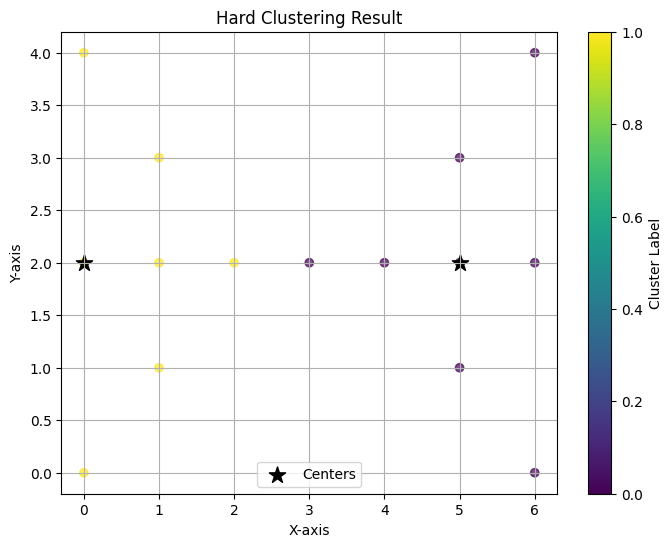

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Butterfly data
X = np.array([0, 0, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 6, 6, 6])
Y = np.array([4, 2, 0, 3, 2, 1, 2, 2, 2, 3, 2, 1, 4, 2, 0])
data = np.vstack((X, Y)).T  # Stack X and Y into a 2D array

def custom_hard_clustering(points, k, max_steps=100, threshold=0.001):
    n_points = points.shape[0]
    n_dims = points.shape[1]

    # Randomly assign initial cluster centers from data points
    np.random.shuffle(points)
    cluster_centers = points[:k].copy()

    # Initialize membership array
    memberships = np.zeros(n_points, dtype=int)

    for step in range(max_steps):
        old_memberships = memberships.copy()

        # Step 1: Assign points to nearest center
        for i, point in enumerate(points):
            distances = np.array([np.sqrt(np.sum((point - center) ** 2))
                                for center in cluster_centers])
            memberships[i] = np.argmin(distances)

        # Step 2: Update cluster centers
        for cluster in range(k):
            cluster_points = points[memberships == cluster]
            if len(cluster_points) > 0:  # Avoid empty clusters
                cluster_centers[cluster] = np.mean(cluster_points, axis=0)

        # Check convergence
        if np.all(memberships == old_memberships):
            break

    # Construct U matrix from memberships
    U_matrix = np.zeros((k, n_points))
    for i, cluster in enumerate(memberships):
        U_matrix[cluster, i] = 1

    return U_matrix, cluster_centers, memberships

# Run the algorithm
k = 2
U, centers, labels = custom_hard_clustering(data, k)

# Print results
print("Cluster labels:", '\n', U)
print("Centroids:", '\n', centers)
print("Labels:", '\n', labels)

# Plotting function
def plot_results(data, labels, centers):
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='*', s=150, label='Centers')
    plt.title('Hard Clustering Result')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.colorbar(label='Cluster Label')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize results
plot_results(data, labels, centers)